To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your own computer, follow the installation instructions on our Github page [here](https://docs.unsloth.ai/get-started/installing-+-updating).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


### News

Unsloth now supports Text-to-Speech (TTS) models. Read our [guide here](https://docs.unsloth.ai/basics/text-to-speech-tts-fine-tuning).

Read our **[Qwen3 Guide](https://docs.unsloth.ai/basics/qwen3-how-to-run-and-fine-tune)** and check out our new **[Dynamic 2.0](https://docs.unsloth.ai/basics/unsloth-dynamic-2.0-ggufs)** quants which outperforms other quantization methods!

Visit our docs for all our [model uploads](https://docs.unsloth.ai/get-started/all-our-models) and [notebooks](https://docs.unsloth.ai/get-started/unsloth-notebooks).


### Installation

In [1]:
# !pip install unsloth

### Unsloth

In [2]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Llama-3.2-11B-Vision-Instruct",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    max_seq_length = 128000
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/toby/pagepilot_train/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.6.4: Fast Mllama patching. Transformers: 4.52.4.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.529 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.6. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading checkpoint shards: 100%|██████████| 5/5 [00:41<00:00,  8.39s/it]


In [3]:
print(repr(tokenizer.chat_template))

'{{- bos_token }}\n{%- if custom_tools is defined %}\n    {%- set tools = custom_tools %}\n{%- endif %}\n{%- if not tools_in_user_message is defined %}\n    {%- set tools_in_user_message = true %}\n{%- endif %}\n{%- if not date_string is defined %}\n    {%- if strftime_now is defined %}\n        {%- set date_string = strftime_now("%d %b %Y") %}\n    {%- else %}\n        {%- set date_string = "26 Jul 2024" %}\n    {%- endif %}\n{%- endif %}\n{%- if not tools is defined %}\n    {%- set tools = none %}\n{%- endif %}\n\n{#- This block extracts the system message, so we can slot it into the right place. #}\n{%- if messages[0][\'role\'] == \'system\' %}\n    {%- set system_message = messages[0][\'content\']|trim %}\n    {%- set messages = messages[1:] %}\n{%- else %}\n    {%- set system_message = "" %}\n{%- endif %}\n\n{#- Find out if there are any images #}\n{% set image_ns = namespace(has_images=false) %}      \n{%- for message in messages %}\n    {%- for content in message[\'content\'] %}

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [4]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = False, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


<a name="Data"></a>
### Data Prep
We'll be using a sampled version of the ROCO radiography dataset. You can access the dataset [here](https://huggingface.co/datasets/unsloth/Radiology_mini). The full dataset is [here](https://huggingface.co/datasets/eltorio/ROCOv2-radiology).

The dataset includes X-rays, CT scans and ultrasounds showcasing medical conditions and diseases. Each image has a caption written by experts describing it. The goal is to finetune a VLM to make it a useful analysis tool for medical professionals.


In [5]:
import json
def load_jsonl(file_path, encoding='utf-8'):
    with open(file_path, 'r', encoding=encoding) as file:
        return [json.loads(line) for line in file]

# dataset = load_jsonl("train_GAIA_gemini_25_pro.jsonl") # Load your dataset
dataset = load_jsonl("train_v3.jsonl", encoding='utf-8-sig') # Load your dataset

Let's take a look at the dataset, and check what the 1st example shows:

{'messages': [{'role': 'system',
   'content': 'Imagine you are a robot browsing the web, just like humans. Now you need to complete a task. In each iteration, you will receive an Observation that includes a screenshot of a webpage and some texts. This screenshot will feature Numerical Labels placed in the TOP LEFT corner of each Web Element.\nCarefully analyze the visual information to identify the Numerical Label corresponding to the Web Element that requires interaction, then follow the guidelines and choose one of the following actions:\n1. Click a Web Element.\n2. Delete existing content in a textbox and then type content. \n3. Scroll up or down. Multiple scrolls are allowed to browse the webpage. Pay attention!! The default scroll is the whole window. If the scroll widget is located in a certain area of the webpage, then you have to specify a Web Element in that area. I would hover the mouse there and then scroll.\n4. Wait. Typically used to wait for unfinished webpage processes,
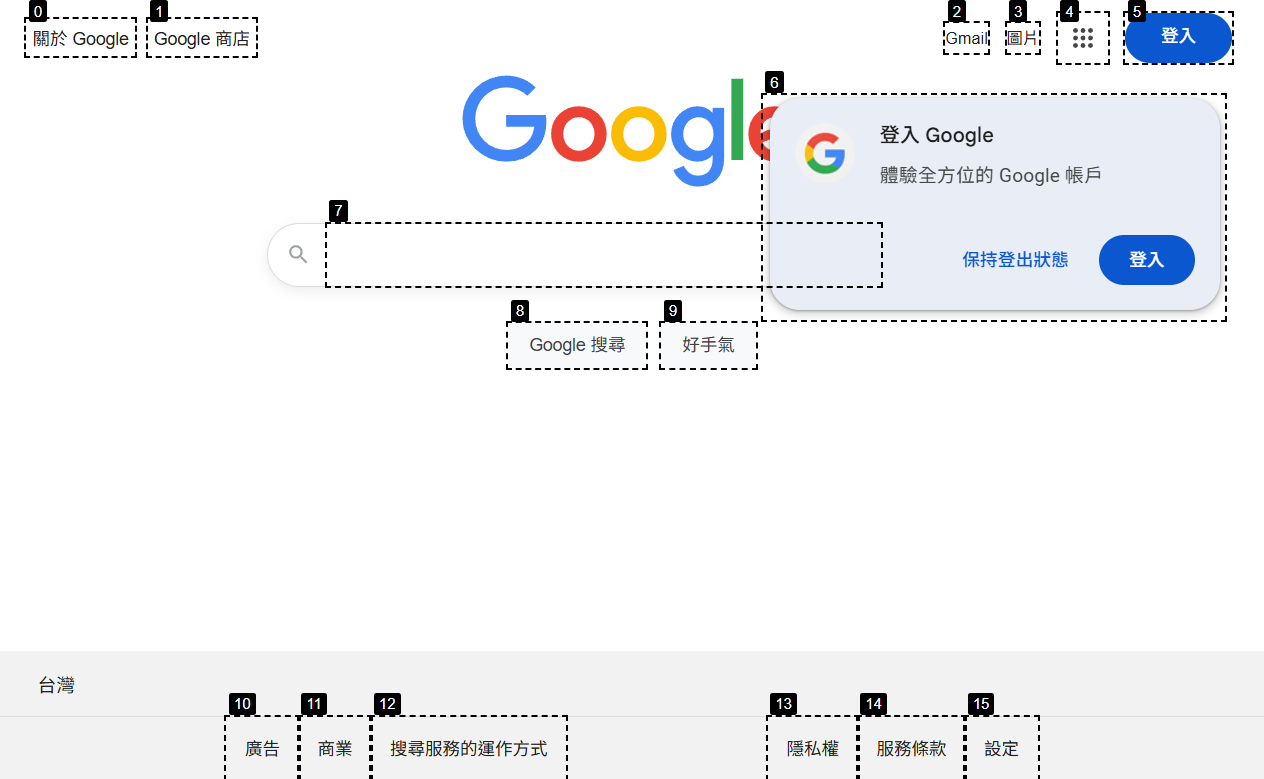
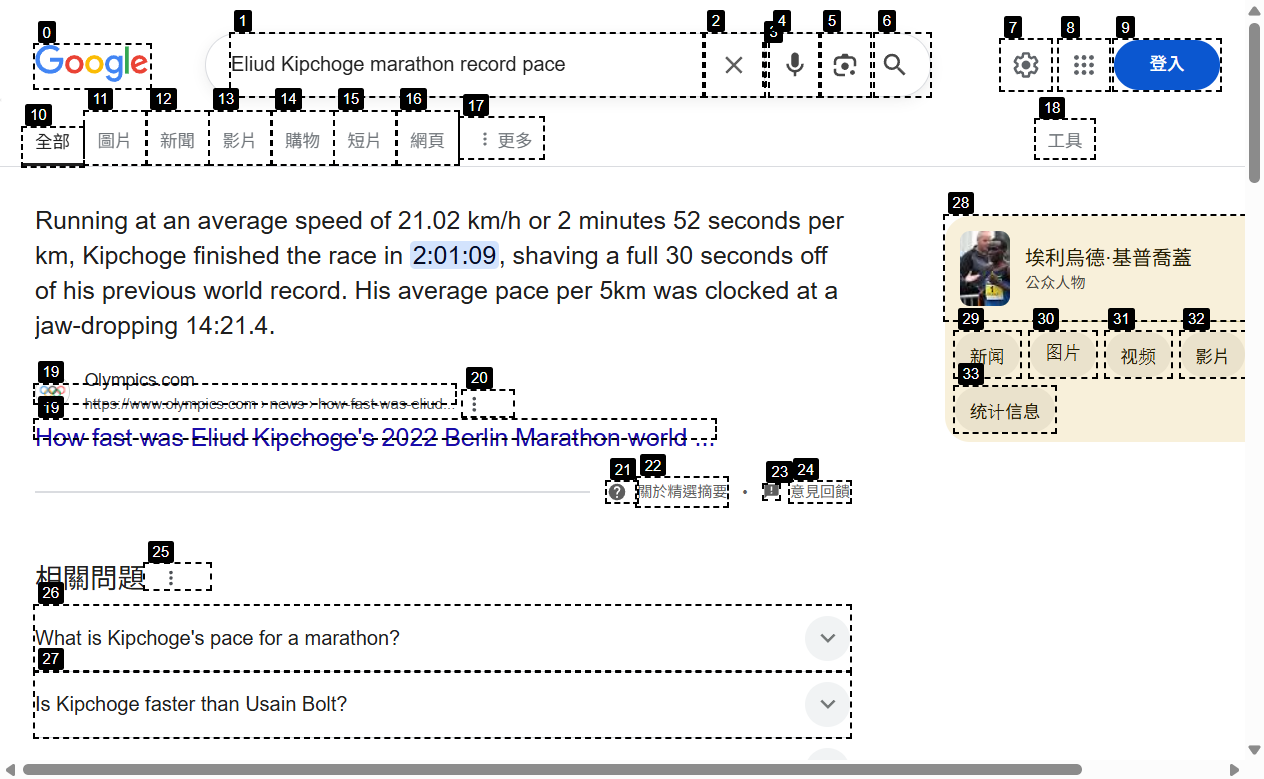
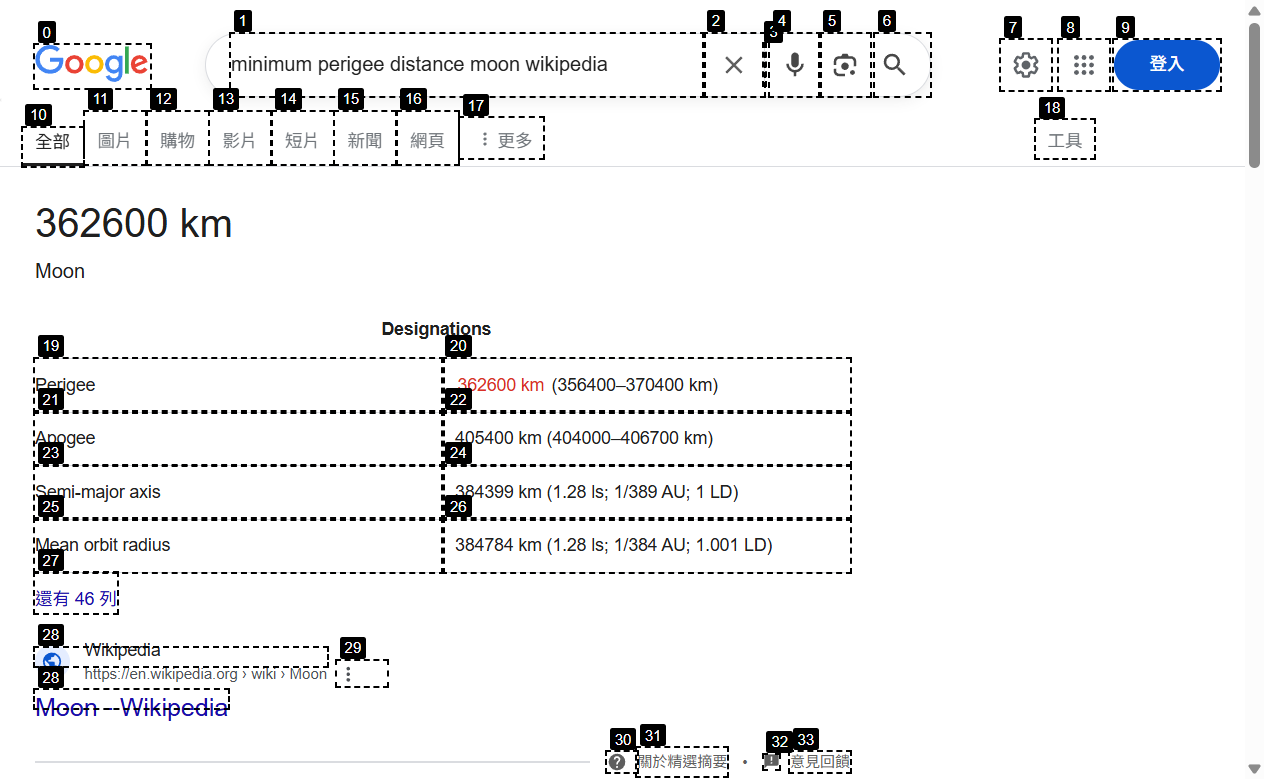

In [6]:
dataset[0]

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": instruction}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": answer} ]
},
]
```

We will craft an custom instruction asking the VLM to be an expert radiographer. Notice also instead of just 1 instruction, you can add multiple turns to make it a dynamic conversation.

In [7]:
def clip_message_and_obs(msg, max_img_num):
    clipped_msg = []
    img_num = 0
    for idx in range(len(msg)):
        curr_msg = msg[len(msg) - 1 - idx]
        if curr_msg['role'] != 'user':
            clipped_msg = [curr_msg] + clipped_msg
        else:
            if type(curr_msg['content']) == str:
                clipped_msg = [curr_msg] + clipped_msg
            elif img_num < max_img_num:
                img_num += 1
                clipped_msg = [curr_msg] + clipped_msg
            else:
                msg_no_pdf = curr_msg['content'][0]["text"].split("Observation:")[0].strip() + "Observation: A screenshot and some texts. (Omitted in context.)"
                msg_pdf = curr_msg['content'][0]["text"].split("Observation:")[0].strip() + "Observation: A screenshot, a PDF file and some texts. (Omitted in context.)"
                curr_msg_clip = {
                    'role': curr_msg['role'],
                    'content': msg_no_pdf if "You downloaded a PDF file" not in curr_msg['content'][0]["text"] else msg_pdf
                }
                clipped_msg = [curr_msg_clip] + clipped_msg
    return clipped_msg

In [8]:
import base64
from io import BytesIO
from PIL import Image
import re

def base64_to_pil_image(base64_str):
    if base64_str.startswith("data:image/png;base64,"):
        base64_str = base64_str.split(",", 1)[1]
    image_data = base64.b64decode(base64_str)
    image = Image.open(BytesIO(image_data))
    return image

def process_format(data:list):
    data = data.copy()['messages']
    for row in data:
        if row['role']=='system':
            row['role'] = 'user'

        if type(row['content']) is list:
            for i, content in enumerate(row['content']):                
                if content['type']=='image_url':
                    row['content'][i] = {'type':'image', 'image':base64_to_pil_image(content['image_url']['url'])}
        elif type(row['content']) is dict:
            # if row['content']['type']=='image_url':
            #         row['content'] = [{'type':'image', 'image':base64_to_pil_image(row['content']['image_url']['url'])}]
            # else:
            row['content'] = [row['content']]

    groups = []
    first = data[0]
    rest = data[1:]
    match = re.search(r"Now given a task:(.*?)Please interact with", rest[0]['content'][0]['text'], re.DOTALL)
    task_info = 'Now given a task: '+match.group(1).strip()
    # print(task_info)
    # for i in range(0, len(rest), 6):
    for i in range(0, len(rest), 6): # remove data after 3 round
        group = [first] + clip_message_and_obs(rest[i:i+6], 3) # max_img_num=3
        if i!=0:
            group[1]['content'][0]['text'] = task_info + group[1]['content'][0]['text'] # add task info
        groups.append({'messages':group})
    return groups


Let's convert the dataset into the "correct" format for finetuning:

In [9]:
# converted_dataset = [convert_to_conversation(sample) for sample in dataset]
converted_dataset = []
for sample in dataset:
    converted_dataset.extend(process_format(sample))

In [10]:
converted_dataset[9]

{'messages': [{'role': 'user',
   'content': 'Imagine you are a robot browsing the web, just like humans. Now you need to complete a task. In each iteration, you will receive an Observation that includes a screenshot of a webpage and some texts. This screenshot will feature Numerical Labels placed in the TOP LEFT corner of each Web Element.\nCarefully analyze the visual information to identify the Numerical Label corresponding to the Web Element that requires interaction, then follow the guidelines and choose one of the following actions:\n1. Click a Web Element.\n2. Delete existing content in a textbox and then type content. \n3. Scroll up or down. Multiple scrolls are allowed to browse the webpage. Pay attention!! The default scroll is the whole window. If the scroll widget is located in a certain area of the webpage, then you have to specify a Web Element in that area. I would hover the mouse there and then scroll.\n4. Wait. Typically used to wait for unfinished webpage processes, w

The first example is now structured like below:

Before we do any finetuning, maybe the vision model already knows how to analyse the images? Let's check if this is the case!

In [11]:
from qwen_vl_utils import process_vision_info
FastVisionModel.for_inference(model) # Enable for inference!


input_text = tokenizer.apply_chat_template(dataset[0]['messages'][0:2], add_generation_prompt = True)
image_inputs, video_inputs = process_vision_info(dataset[0]['messages'][0:2])
inputs = tokenizer(
    text = input_text,
    images = image_inputs,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")


from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 12800,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Thoughts: The image shows a search results page for Google, with several web elements labeled. We need to find the action to take, as outlined in the given tasks.

Action: Answer<|eot_id|>


<a name="Train"></a>
### Train the model
Now let's use Huggingface TRL's `SFTTrainer`! More docs here: [TRL SFT docs](https://huggingface.co/docs/trl/sft_trainer). We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [12]:
from unsloth.trainer import UnslothVisionDataCollator
data_collector = UnslothVisionDataCollator(model, tokenizer, max_seq_length=128000)
data_collector.max_seq_length, data_collector.truncation, data_collector.image_size

(128000, True, 560)

In [13]:
import random
# from datasets import Dataset
random.shuffle(converted_dataset)

train_eval_ratio = 0.9
split_index = int(len(converted_dataset) * train_eval_ratio)
train_dataset, eval_dataset = converted_dataset[:split_index], converted_dataset[split_index:]

# train_dataset = Dataset.from_list(train_dataset)
# eval_dataset = Dataset.from_list(eval_dataset)

len(train_dataset), len(eval_dataset)

(654, 73)

In [14]:
from unsloth import is_bf16_supported
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collector, # Must use!
    train_dataset = train_dataset,
    eval_dataset= eval_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 3,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 75,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 4,
        max_length = 128000,

        # do eval
        eval_strategy="steps",
        do_eval=True,
        eval_steps=1,
    ),
)

# from unsloth.chat_templates import train_on_responses_only
# trainer = train_on_responses_only(
#     trainer, 
#     instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
#     response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
# )

In [15]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA RTX A6000. Max memory = 47.529 GB.
20.814 GB of memory reserved.


In [16]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 654 | Num Epochs = 2 | Total steps = 75
O^O/ \_/ \    Batch size per device = 3 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (3 x 4 x 1) = 12
 "-____-"     Trainable parameters = 17,039,360/10,687,260,195 (0.16% trained)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
1,3.208700,3.405163
2,3.756900,3.379791
3,3.126500,3.203580
4,3.463500,2.808742
5,3.003400,2.470389
6,2.587100,2.294074
7,2.270600,2.178312
8,2.008800,2.086434
9,1.976100,2.023582
10,2.054500,1.970016


Unsloth: Not an error, but MllamaForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


In [17]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

18101.5012 seconds used for training.
301.69 minutes used for training.
Peak reserved memory = 33.262 GB.
Peak reserved memory for training = 12.448 GB.
Peak reserved memory % of max memory = 69.983 %.
Peak reserved memory for training % of max memory = 26.19 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [18]:
# FastVisionModel.for_inference(model) # Enable for inference!

# image = dataset[0]["image"]
# instruction = "You are an expert radiographer. Describe accurately what you see in this image."

# messages = [
#     {"role": "user", "content": [
#         {"type": "image"},
#         {"type": "text", "text": instruction}
#     ]}
# ]
# input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
# inputs = tokenizer(
#     image,
#     input_text,
#     add_special_tokens = False,
#     return_tensors = "pt",
# ).to("cuda")

# from transformers import TextStreamer
# text_streamer = TextStreamer(tokenizer, skip_prompt = True)
# _ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
#                    use_cache = True, temperature = 1.5, min_p = 0.1)

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [19]:
train_name = 'llama32_11b_lora_v11_dataset_flatten'  # Change this to your desired training name
model.save_pretrained(f"model_{train_name}")  # Local saving
tokenizer.save_pretrained(f"model_{train_name}")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

[]

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [20]:
# if False:
from unsloth import FastVisionModel
model, tokenizer = FastVisionModel.from_pretrained(
    model_name = f"model_{train_name}", # YOUR MODEL YOU USED FOR TRAINING
    load_in_4bit = False, # Set to False for 16bit LoRA
    max_seq_length = 128000
)
FastVisionModel.for_inference(model) # Enable for inference!

input_text = tokenizer.apply_chat_template(dataset[0]['messages'][0:2], add_generation_prompt = True)
image_inputs, video_inputs = process_vision_info(dataset[0]['messages'][0:2])
inputs = tokenizer(
    text = input_text,
    images = image_inputs,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")


from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 12800,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

==((====))==  Unsloth 2025.6.4: Fast Mllama patching. Transformers: 4.52.4.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.529 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.6. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading checkpoint shards: 100%|██████████| 5/5 [00:03<00:00,  1.36it/s]


Thought: To calculate how many thousand hours it would take Eliud Kipchoge to run the distance between the Earth and the Moon, we first need to determine his marathon pace. Given that his record marathon pace is approximately 5.805 m/s or 20.898 km/h, and the Moon's closest approach is about 356,400 km. Then we'll use these values to calculate the time.
Action: Type [7]; 20.898 km/h<|eot_id|>


In [21]:
dataset[0]['messages'][2]

{'role': 'assistant',
 'content': "Thought: The task is to calculate the time in thousand hours it would take Eliud Kipchoge to run the distance between the Earth and the Moon at its closest approach (minimum perigee), maintaining his marathon record pace. I need to find two key pieces of information: Kipchoge's marathon record pace (in km/h) and the minimum perigee distance of the Moon (in km). Then I will perform the calculation: Time (hours) = Distance (km) / Pace (km/h), convert hours to thousand hours by dividing by 1000, and round the result to the nearest integer (thousand hours).\n\nFirst, I will search for Eliud Kipchoge's marathon record pace. I'll use the search bar [7] on the Google page.\nAction: Type 7; Eliud Kipchoge marathon record pace"}

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [22]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
model.save_pretrained_merged(f"unsloth_{train_name}", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "PUT_HERE")

Found HuggingFace hub cache directory: /home/toby/.cache/huggingface/hub
Checking cache directory for required files...
Successfully copied all 5 files from cache to unsloth_llama32_11b_lora_v11_dataset_flatten.


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [01:30<00:00, 18.04s/it]


And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other links:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
6. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://docs.unsloth.ai/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️
</div>
